# Projection dans l'espace latent $\mathcal{W}$ de StyleGAN2

Ce notebook implémente la projection par optimisation dans l'espace latent $\mathcal{W}$ du générateur StyleGAN2-FFHQ (512×512).


**Pipeline :**
1. Alignement du visage (landmarks dlib → recadrage style FFHQ)
2. Estimation des statistiques de $\mathcal{W}$ ($\mu_w$, $\sigma_w$)
3. Optimisation conjointe de $w$ et des noise buffers via Adam (1 100 itérations)
4. Visualisation des pertes, schedules, noise buffers et résultat final

## 1. Imports

In [ ]:
import sys
import os
import pickle
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF

from lpips import LPIPS
import dlib
from download_ffhq import recreate_aligned_images

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2.torch_utils.misc import get_device
import stylegan2.torch_utils.custom_ops as custom_ops

SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

custom_ops.force_disable_problematic_cuda_kernels = True
device = get_device()
print(f'Device : {device}')
print(f'CUDA : {torch.cuda.is_available()}')

# https://huggingface.co/DragGan/DragGan-Models/blob/20dedd0259ff3009fceefa531c3be8ae4f11cd82/stylegan2-ffhq-512x512.pkl
with open('models/stylegan2-ffhq-512x512.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
for p in G.parameters():
    p.requires_grad = False
print(f'StyleGAN2 chargé.  z_dim={G.z_dim}, w_dim={G.w_dim}, num_ws={G.mapping.num_ws}')

c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
CUDA : True
StyleGAN2 chargé.  z_dim=512, w_dim=512, num_ws=16


## 2. Fonctions utilitaires

In [2]:
def imshow(images, titles=None, gray=False):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray' if gray else None)
        ax.axis('off')
        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()


def tensor_to_img(t: torch.Tensor) -> np.ndarray:
    arr = t.detach().permute(0, 2, 3, 1).cpu().numpy()
    arr = np.clip((arr + 1) / 2, 0, 1)
    return arr[0] if t.shape[0] == 1 else arr


def w_to_image(w: torch.Tensor) -> np.ndarray:
    if w.shape[1] == 1:
        w = w.repeat([1, G.mapping.num_ws, 1])
    pred = G.synthesis(w, noise_mode='const')
    return tensor_to_img(pred)

## 3. LPIPS

In [3]:
lpips_fn = LPIPS(net='vgg').to(device).eval()
for p in lpips_fn.parameters():
    p.requires_grad = False
print('LPIPS (VGG) chargé.')

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth
LPIPS (VGG) chargé.


## 4. Alignement des visages

StyleGAN2-FFHQ a été entraîné sur des visages alignés (68 landmarks dlib). Pour projeter une image quelconque, on peut d'abord la recadrer de la même façon, mais l'alignement rigoureux ne s'est pas montré nécessaire.

In [4]:
detector  = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('models/shape_predictor_68_face_landmarks.dat')


def extract_face_landmarks(img_path: str) -> list:
    img  = dlib.load_rgb_image(img_path)
    dets = detector(img, 1)
    if len(dets) == 0:
        raise ValueError(f'Aucun visage détecté dans {img_path}')
    shape = predictor(img, dets[0])
    return [[p.x, p.y] for p in shape.parts()]


def align_faces(input_dir: str, output_dir: str):
    landmarks_list = {}
    for filename in os.listdir(input_dir):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(input_dir, filename)
        try:
            lm = extract_face_landmarks(img_path)
            landmarks_list[filename] = {
                'in_the_wild': {'file_path': filename, 'face_landmarks': lm}
            }
            print(f'  {filename}, OK')
        except Exception as e:
            print(f'  {filename}, erreur : {e}')
    recreate_aligned_images(landmarks_list, input_dir, output_dir)

In [ ]:
align_faces('./images_to_align', './images_aligned')

## 5. Projection dans $\mathcal{W}$

On optimise un vecteur $w \in \mathcal{W}$ **et** les noise buffers du synthétiseur pour minimiser :

$$\mathcal{L} = \lambda_{\text{LPIPS}} \cdot \text{LPIPS}(G(w), x) + \lambda_{\text{pix}} \cdot \|G(w) - x\|^2_2 + \lambda_{\text{bruit}} \cdot \mathcal{L}_{\text{reg}}$$

où $\mathcal{L}_{\text{reg}}$ pénalise les corrélations spatiales dans les noise buffers. Un bruit d'exploration sur $w$ diminue au fil des itérations, et le learning rate suit un schedule cosinus avec warm-up.

In [16]:
def compute_w_stats(n_samples: int = 2500):
    """Estime la moyenne et l'écart-type de W par échantillonnage aléatoire."""
    samples = []
    for _ in tqdm(range(n_samples), desc='W stats', leave=False):
        z = torch.randn([1, G.z_dim], device=device)
        w = G.mapping(z, None)
        samples.append(w)
    w_all = torch.cat(samples, dim=0)
    return w_all.mean(dim=0, keepdim=True), w_all.std(dim=0, keepdim=True)


def noise_reg_loss(noise_bufs: dict) -> torch.Tensor:
    """Pénalise les corrélations spatiales dans les noise buffers."""
    loss = torch.zeros(1, device=device)
    for buf in noise_bufs.values():
        loss += torch.mean(buf * torch.roll(buf, shifts=1, dims=0)) ** 2
        loss += torch.mean(buf * torch.roll(buf, shifts=1, dims=1)) ** 2
    return loss

In [21]:
def project(
    im_path: str,
    n_iters: int = 1100,
    loss_weights: tuple = (2.0, 2.0, 1e5),
    verbose: bool = False,
):
    """
    Projette une image dans W.

    Retourne
    --------
    best_w       : torch.Tensor (1,1,512)
    target       : torch.Tensor (1,3,512,512)
    noise_bufs   : dict, noise buffers optimisés
    history      : dict, {'total','lpips','pixel','noise'}
    lrs          : list, valeurs du learning rate schedule
    noise_scales : list, valeurs du noise scale schedule
    """
    pixel_w, vgg_w, noise_w = loss_weights

    w_avg, w_std = compute_w_stats()

    bgr = cv2.imread(im_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    target = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).float().to(device)
    target = (target / 127.5) - 1.0
    target = TF.resize(target, (512, 512))

    w_param = nn.Parameter(w_avg.clone())
    best_w = w_avg.clone().detach()
    min_loss = torch.tensor(float('inf'))

    noise_bufs = {
        name: buf
        for name, buf in G.synthesis.named_buffers()
        if 'noise_const' in name
    }
    for buf in noise_bufs.values():
        buf.requires_grad = False
        buf[:] = torch.randn_like(buf)
        buf.requires_grad = True
    best_noise = {k: v.clone().detach() for k, v in noise_bufs.items()}

    optimizer = torch.optim.Adam([w_param] + list(noise_bufs.values()))

    history = {'total': [], 'lpips': [], 'pixel': [], 'noise': []}
    lrs = []
    noise_scales = []

    for it in tqdm(range(n_iters), desc='Projection'):
        t = it / n_iters

        ns = max(0.0, 1.0 - t / 0.75) ** 2
        noise_scales.append(ns)

        lr_ramp = min(1.0, (1.0 - t) / 0.25)
        lr_ramp = 0.5 - 0.5 * np.cos(lr_ramp * np.pi)
        lr_ramp = lr_ramp * min(1.0, t / 0.05)
        lrs.append(lr_ramp)
        for pg in optimizer.param_groups:
            pg['lr'] = 0.1 * lr_ramp

        w_noise = torch.randn_like(w_param) * (w_std * 0.05 * ns)
        w = (w_param + w_noise)
        pred = G.synthesis(w, noise_mode='const')

        loss_lpips = vgg_w   * lpips_fn(pred, target).mean()
        loss_pixel = pixel_w * nn.MSELoss()(pred, target)
        loss_noise = noise_w * noise_reg_loss(noise_bufs)
        loss = loss_lpips + loss_pixel + loss_noise

        if loss < min_loss:
            min_loss = loss.detach()
            best_w = w_param.clone().detach()
            best_noise = {k: v.clone().detach() for k, v in noise_bufs.items()}

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            for buf in noise_bufs.values():
                buf -= buf.mean()
                buf /= buf.std() + 1e-10

        history['total'].append(loss.item())
        history['lpips'].append(loss_lpips.item())
        history['pixel'].append(loss_pixel.item())
        history['noise'].append(loss_noise.item())

        if verbose and it % 100 == 0:
            print(f'[{it:4d}] total={loss.item():.4f}  '
                  f'lpips={loss_lpips.item():.4f}  '
                  f'pixel={loss_pixel.item():.4f}  '
                  f'noise={loss_noise.item():.4f}')

    for name, buf in noise_bufs.items():
        buf.requires_grad = False
        buf.data.copy_(best_noise[name])

    print(f'Best loss : {min_loss.item():.4f}')
    return best_w, target, noise_bufs, history, lrs, noise_scales

### 5.1 Affichage des pertes

In [18]:
def plot_losses(history: dict, skip: int = 50):
    i = np.arange(skip, len(history['total']))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(i, np.array(history['lpips'])[i], color='steelblue')
    axes[0].set_title('LPIPS loss')

    axes[1].plot(i, np.array(history['pixel'])[i], color='darkorange')
    axes[1].set_title('Pixel loss (MSE)')

    axes[2].plot(i, np.array(history['noise'])[i], color='seagreen')
    axes[2].set_title('Noise reg loss')

    for ax in axes:
        ax.set_xlabel('Itération')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Évolution des pertes (après warm-up)', fontsize=13)
    plt.tight_layout()
    plt.show()

### 5.2 Évolution du bruit et du learning rate

In [10]:
def plot_schedules(lrs: list, noise_scales: list):
    iters = np.arange(len(lrs))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(iters, lrs, color='royalblue')
    ax1.set_title('Learning rate schedule')
    ax1.set_xlabel('Itération')
    ax1.set_ylabel('lr_ramp (x 0.1)')
    ax1.grid(True, alpha=0.3)

    ax2.plot(iters, noise_scales, color='tomato')
    ax2.set_title('Noise scale schedule')
    ax2.set_xlabel('Itération')
    ax2.set_ylabel('noise_scale')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Schedules de bruit et de learning rate', fontsize=13)
    plt.tight_layout()
    plt.show()

### 5.3 Noise buffers

In [19]:
def show_noise_bufs(noise_bufs: dict, max_show: int = 8):
    items = list(noise_bufs.items())
    step = max(1, len(items) // max_show)
    sel = items[::step][:max_show]
    images = [buf.detach().cpu().numpy() for _, buf in sel]
    titles = [name.split('.')[-2] for name, _ in sel]
    imshow(images, titles, gray=True)

### 5.4 Test — projection complète

Projection:   0%|          | 1/1100 [00:00<07:27,  2.45it/s] 

[   0] total=5906.1797  lpips=1.1698  pixel=0.4813  noise=5904.5288


Projection:   9%|▉         | 102/1100 [00:18<02:58,  5.58it/s]

[ 100] total=4.1454  lpips=0.4436  pixel=0.0291  noise=3.6728


Projection:  18%|█▊        | 201/1100 [00:37<03:01,  4.94it/s]

...

[ 900] total=0.3167  lpips=0.2940  pixel=0.0155  noise=0.0072


Projection:  91%|█████████ | 1002/1100 [02:48<00:15,  6.26it/s]

[1000] total=0.3006  lpips=0.2856  pixel=0.0150  noise=0.0000


Projection: 100%|██████████| 1100/1100 [03:04<00:00,  5.98it/s]


Best loss : 0.2996


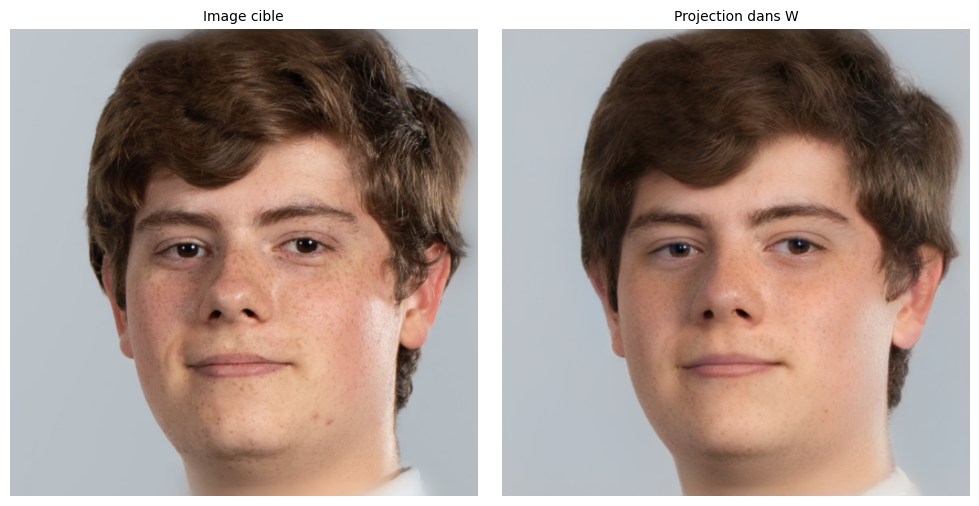

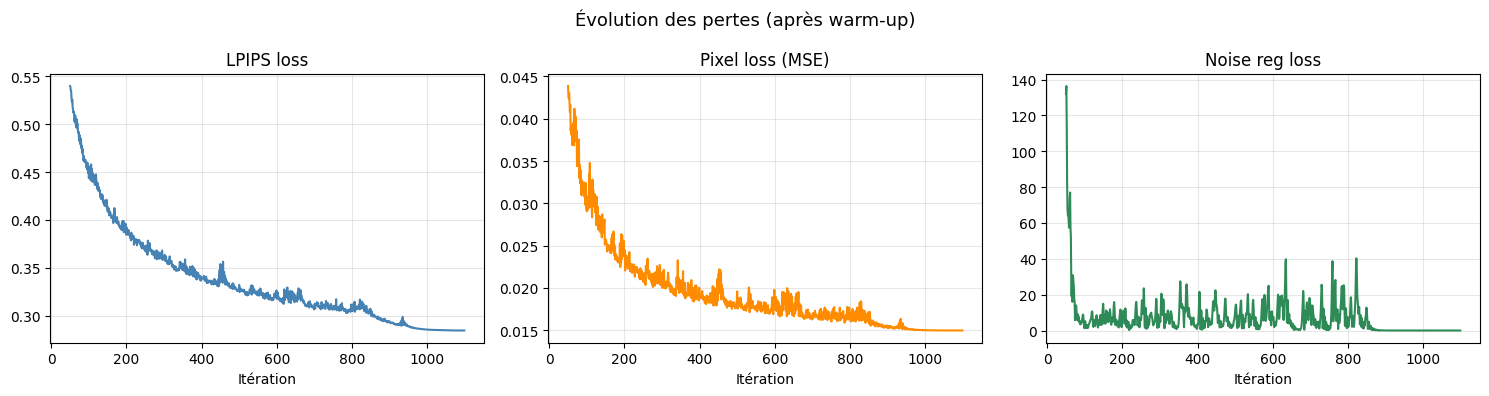

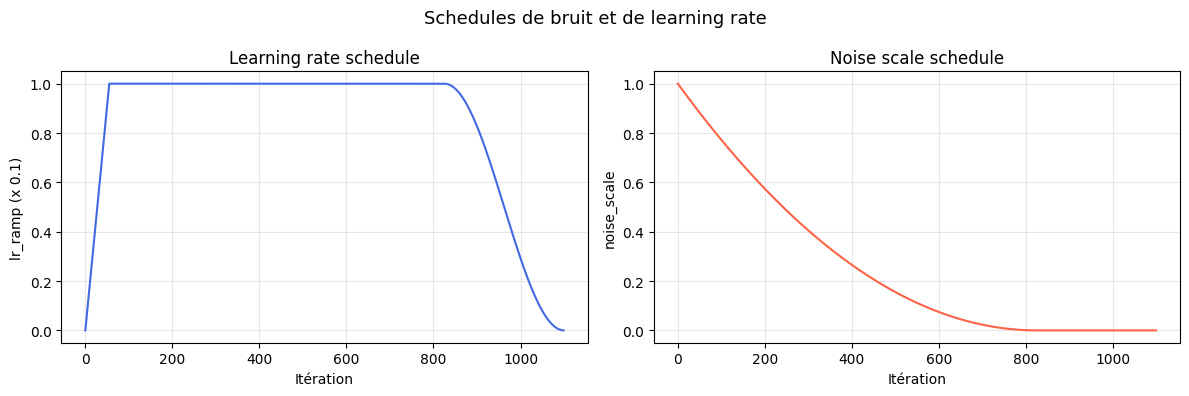

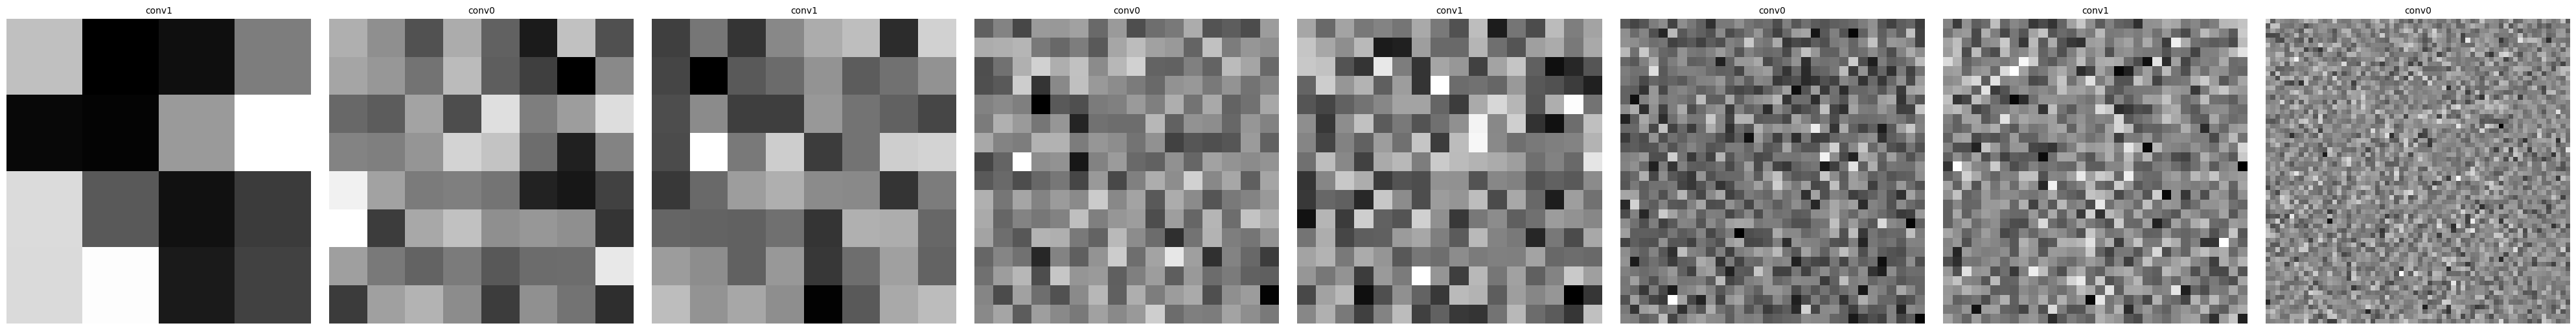

In [22]:
IM_PATH = './images_aligned/antonin2.png'

best_w, target, noise_bufs, history, lrs, noise_scales = project(
    IM_PATH,
    n_iters=1100,
    loss_weights=(2.0, 2.0, 1e5),
    verbose=True,
)

proj_img = w_to_image(best_w)
target_img = tensor_to_img(target)
imshow([target_img, proj_img], ['Image cible', 'Projection dans W'])

plot_losses(history)

plot_schedules(lrs, noise_scales)

show_noise_bufs(noise_bufs)